# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

WHO

The primary audience for this data story are public health researchers, analysts, health care providers, policy makers, community health organizations and students and educators interested in epidemiology, health data, or modeling. This data could also be used to plan interventions or to evaluate where prevention efforts could be targeted based on risk factors.

WHAT

Using the CDC Diabetes Health Indicators dataset contains survey responses from roughly 253,680 U.S. adults, focusing on how lifestyle and health indicators relate to diabetes prevalence. Key insights include which modifiable risk factors, such as BMI, smoking status, and physical activity, are associated with higher diabetes rates, how demographic characteristics like age, sex, income, and education relate to diabetes prevalence, as well as comorbidities such as high blood pressure and high cholesterol, contribute to diabetes risk. The dataset also allows users to explore which combinations or behaviors or conditions leads to greater risk.

HOW

To present this story effectively, a combination of visualizations can be used. Bar plots can show diabetes prevalence across different demographic categories and heatmaps or clustered bar charts can highlight combinations of risk factors.

# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [2]:
pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from ucimlrepo import fetch_ucirepo 
  
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 
  
print(cdc_diabetes_health_indicators.metadata) 
  
print(cdc_diabetes_health_indicators.variables) 


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [4]:

import pandas as pd
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df = pd.concat([X, y], axis=1)

null_counts = df.isnull().sum()

total_nulls = df.isnull().sum().sum()

print("Null values per column:")
print(null_counts)
print("\nTotal null or blank fields in the dataset:", total_nulls)

Null values per column:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

Total null or blank fields in the dataset: 0


In [5]:
invalid_ages = df[df['Age'] < 0]

num_invalid_ages = invalid_ages.shape[0]

print("Number of rows with Age < 0:", num_invalid_ages)

print(invalid_ages.head())

Number of rows with Age < 0: 0
Empty DataFrame
Columns: [HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, Diabetes_binary]
Index: []

[0 rows x 22 columns]


In [7]:
#Testing for odd data: Children who are smokers:

children = df[df['Age'] < 0]

child_smokers = children[children['Smoker'] == 1]

num_child_smokers = child_smokers.shape[0]

print("Number of children who are smokers:", num_child_smokers)

print(child_smokers.head())

Number of children who are smokers: 0
Empty DataFrame
Columns: [HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, Diabetes_binary]
Index: []

[0 rows x 22 columns]


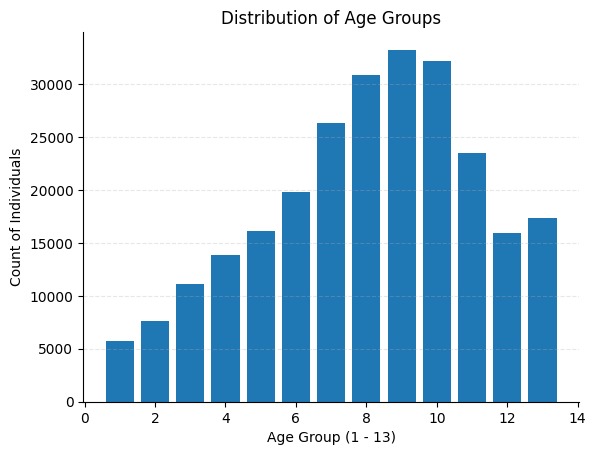

In [10]:
#Checking for a good distribution of ages

age_counts = X['Age'].value_counts().sort_index()

plt.figure()
plt.bar(age_counts.index, age_counts.values)

plt.xlabel("Age Group (1 - 13)")
plt.ylabel("Count of Individuals")
plt.title("Distribution of Age Groups")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Conclusions: After testing for null values and looking for children with ages less that zero, and children who are smokers (a test to look for inconsistent data), I've found tha the data is usable and shouldn't need to be modified. 

I also tested to see if there was a good distribution of ages and was satisfied with what I found.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


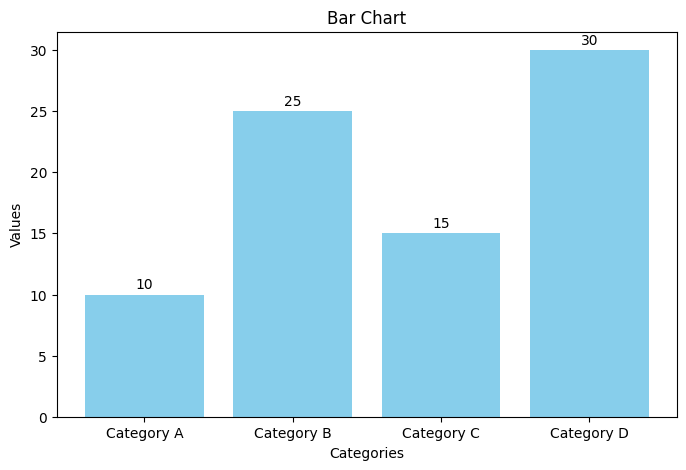

In [7]:
!pip install matplotlib
import matplotlib.pyplot as plt

categories = ['Category A', 'Category B', 'Category C', 'Category D']
values = [10, 25, 15, 30]  

plt.figure(figsize=(8,5))
plt.bar(categories, values, color='skyblue')

plt.title('Bar Chart')
plt.xlabel('Categories')
plt.ylabel('Values')


for i, v in enumerate(values):
    plt.text(i, v + 0.5, str(v), ha='center')

plt.show()